# Dataset Preprocessing

## Imports

In [54]:
import tensorflow as tf
import pandas as pd
import matplotlib.pyplot as plt
import requests

## Reading the Data

In [55]:
CSV_PATH = "SimThresh_T_A2_T_0.99_0.70_FC_T_KeepOne_Out_T_OutThresh_None_0FST_F.csv"
df = pd.read_csv(CSV_PATH)
df.head()

,filepath,filename,diag,fst,partition,md5hash,fitzpatrick,label,nine_partition_label,three_partition_label,qc,url,url_alphanum,orig_img_name,new_img_name
0,ne-de_361/ne-de_f2_61_3a96728f.jpg,ne-de_f2_61_3a96728f,ne-de,2,train,3a96728fb161fc25b3597d3996dc4e4a,2,neutrophilic dermatoses,inflammatory,non-neoplastic,NaN,https://www.dermaamin.com/site/images/clinical...,httpwwwdermaamincomsiteimagesclinicalpicppyode...,3a96728fb161fc25b3597d3996dc4e4a.jpg,ne-de_f2_61_3a96728f.jpg
1,lu-er_410/lu-er_f1_89_07be6be3.jpg,lu-er_f1_89_07be6be3,lu-er,1,train,07be6be3cbebd04ff9bfcab50b75378b,1,lupus erythematosus,inflammatory,non-neoplastic,NaN,https://www.dermaamin.com/site/images/clinical...,httpwwwdermaamincomsiteimagesclinicalpicssubac...,07be6be3cbebd04ff9bfcab50b75378b.jpg,lu-er_f1_89_07be6be3.jpg
2,me_261/me_f0_194_72bcd875.jpg,me_f0_194_72bcd875,me,0,train,72bcd875e7a573b4139883059e69328d,-1,melanoma,malignant melanoma,malignant,NaN,http://atlasdermatologico.com.br/img?imageId=4264,httpwwwatlasdermatologicocombrimgimageId4264.jpg,72bcd875e7a573b4139883059e69328d.jpg,me_f0_194_72bcd875.jpg
3,dr-er_200/dr-er_f4_36_dfa97968.jpg,dr-er_f4_36_dfa97968,dr-er,4,train,dfa9796851f899e99961603c951742fa,4,drug eruption,inflammatory,non-neoplastic,NaN,https://www.dermaamin.com/site/images/clinical...,httpwwwdermaamincomsiteimagesclinicalpicddruge...,dfa9796851f899e99961603c951742fa.jpg,dr-er_f4_36_dfa97968.jpg
4,ju-xa_149/ju-xa_f2_118_be506d4a.jpg,ju-xa_f2_118_be506d4a,ju-xa,2,train,be506d4a799385099ac85daa695d6df3,2,juvenile xanthogranuloma,inflammatory,non-neoplastic,NaN,http://atlasdermatologico.com.br/img?imageId=8098,httpwwwatlasdermatologicocombrimgimageId8098.jpg,be506d4a799385099ac85daa695d6df3.jpg,ju-xa_f2_118_be506d4a.jpg


## Keeping Necessary Columns

In [56]:
keep = [
    "url",
    "filename",
    "diag",
    "fst",
    "partition",
    "label",
    "nine_partition_label",
    "three_partition_label",
]

df = df[keep].copy()
df.head()

,url,filename,diag,fst,partition,label,nine_partition_label,three_partition_label
0,https://www.dermaamin.com/site/images/clinical...,ne-de_f2_61_3a96728f,ne-de,2,train,neutrophilic dermatoses,inflammatory,non-neoplastic
1,https://www.dermaamin.com/site/images/clinical...,lu-er_f1_89_07be6be3,lu-er,1,train,lupus erythematosus,inflammatory,non-neoplastic
2,http://atlasdermatologico.com.br/img?imageId=4264,me_f0_194_72bcd875,me,0,train,melanoma,malignant melanoma,malignant
3,https://www.dermaamin.com/site/images/clinical...,dr-er_f4_36_dfa97968,dr-er,4,train,drug eruption,inflammatory,non-neoplastic
4,http://atlasdermatologico.com.br/img?imageId=8098,ju-xa_f2_118_be506d4a,ju-xa,2,train,juvenile xanthogranuloma,inflammatory,non-neoplastic


## Missing Values

In [57]:
df.isna().sum()

url                      35
filename                  0
diag                      0
fst                       0
partition                 0
label                     0
nine_partition_label      0
three_partition_label     0
dtype: int64

## Getting Rid of the Missing URLs

In [58]:
before = len(df)
df = df.dropna(subset=["url"])
df.isna().sum()

url                      0
filename                 0
diag                     0
fst                      0
partition                0
label                    0
nine_partition_label     0
three_partition_label    0
dtype: int64

## Grouping Skin Tones

In [59]:
df = pd.read_csv(CSV_PATH)

# KEEP ALL FST VALUES INCLUDING 0

def map_tone(f):
    if f in [1, 2]: return "light"
    if f in [3, 4]: return "medium"
    if f in [5, 6]: return "dark"
    return "unknown"  # keep unknown tone

df["skin_tone_group"] = df["fst"].apply(map_tone)

df["skin_tone_group"].value_counts()

skin_tone_group
light      6002
medium     3844
dark       1252
unknown     296
Name: count, dtype: int64

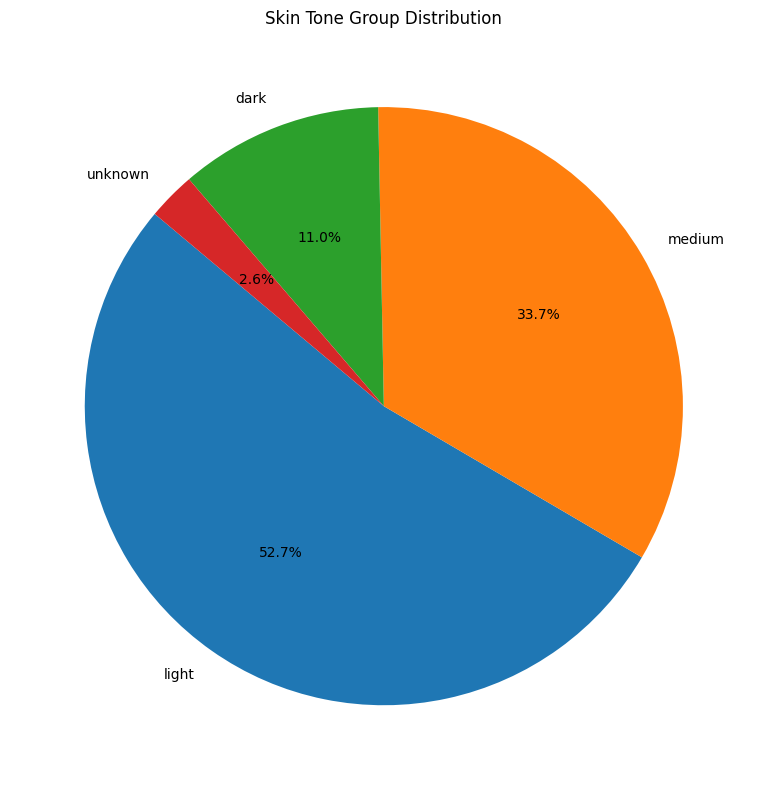

In [60]:
skin_tone_group = df["skin_tone_group"].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(
    skin_tone_group, 
    labels=skin_tone_group.index, 
    autopct="%1.1f%%", 
    startangle=140
)
plt.title("Skin Tone Group Distribution")
plt.tight_layout()
plt.show()

## Lowercase Categorical Fields (Optional)

In [61]:
df["diag"] = df["diag"].str.lower().str.strip()
df["three_partition_label"] = df["three_partition_label"].str.lower().str.strip()
df["nine_partition_label"] = df["nine_partition_label"].str.lower().str.strip()

## Preprocessing 3 Images (Normalizing and Resizing)

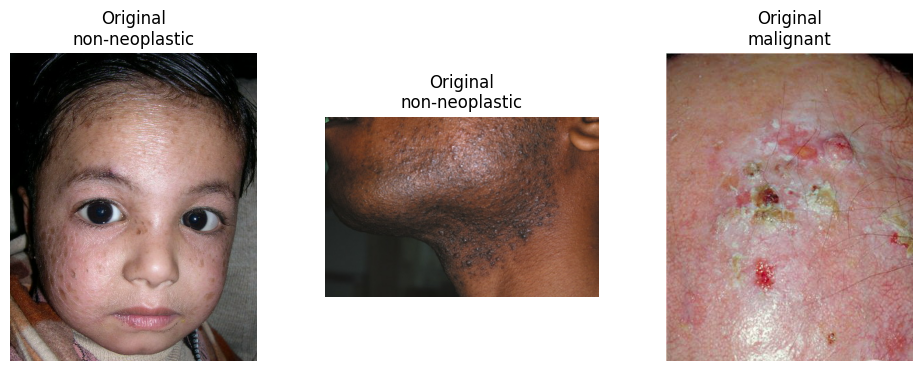

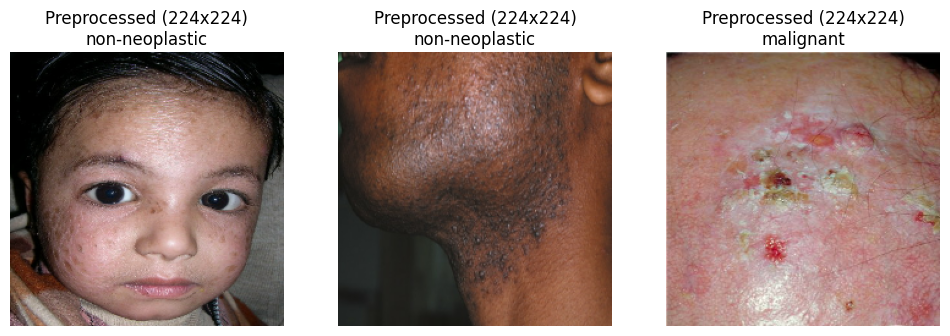

In [62]:
sample = df.sample(3, random_state=42).reset_index(drop=True)

def load_original(url):
    resp = requests.get(url, timeout=10)
    img = tf.io.decode_jpeg(resp.content, channels=3)
    return img.numpy()

def preprocess_image(url):
    resp = requests.get(url, timeout=10)
    img = tf.io.decode_jpeg(resp.content, channels=3)
    img = tf.image.resize(img, [224, 224])
    img = img / 255.0
    return img.numpy()

originals = [load_original(url) for url in sample["url"]]
processed = [preprocess_image(url) for url in sample["url"]]

plt.figure(figsize=(12, 4))
for i, (img, row) in enumerate(zip(originals, sample.itertuples()), 1):
    plt.subplot(1, 3, i)
    plt.imshow(img)
    plt.title(f"Original\n{row.three_partition_label}")
    plt.axis("off")
plt.show()

plt.figure(figsize=(12, 4))
for i, (img, row) in enumerate(zip(processed, sample.itertuples()), 1):
    plt.subplot(1, 3, i)
    plt.imshow(img)
    plt.title(f"Preprocessed (224x224)\n{row.three_partition_label}")
    plt.axis("off")
plt.show()